## **Task 1: Data Import & Setup**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# View Dataset
print(df.head())

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

## **Task 2: Data Cleaning**

In [8]:
# Check Data Types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [14]:
# Convert Date Column
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')

### **Data Cleaning**

In [12]:
# Missing Values

print(df.isnull().sum())

# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


/tmp/ipykernel_521/3820205047.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_521/3820205047.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

### **Remove Duplicates**

In [15]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


### **Standardize Gender**

In [16]:
df['gender'] = df['gender'].str.lower()

df['gender'] = df['gender'].replace({
    'm':'male',
    'f':'female'
})

### **Remove Unrealistic Values**

In [17]:
df = df[df['likes'] >= 0]
df = df[df['comments'] >= 0]
df = df[df['shares'] >= 0]

In [18]:
df['hashtag_count'] = df['hashtags'].fillna('').apply(
    lambda x: len(str(x).split())
)

In [19]:
df['sentiment'] = df['sentiment'].str.strip().str.title()

## **Task 3: Data Exploration**

In [20]:
# Structure

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  female      UK   109864      text          food   4862.0   
3    64886  51.0   other  France   848877      text       fitness   5350.0   
4    16265  34.0   other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile 

In [21]:
# Data Types

print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [23]:
# Summery Statistics

print(df.describe())

            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.997400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5702.293017   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%    1012.0000     4034.5

In [24]:
# Categorical Analysis

print(df['post_type'].value_counts())

print(df['country'].unique())

print(df['country'].nunique())

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
10


In [25]:
# Correlation Matrix

corr = df.corr(numeric_only=True)

print(corr)

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.025811 -0.033395  0.013763   
age              -0.006688  1.000000 -0.013153 -0.036322 -0.007284  0.013871   
post_id           0.020051 -0.013153  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036322  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007284 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.013871  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013322 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.024894 -0.002844 -0.022982 -0.011733 -0.010783   
is_verified       0.004058 -0.000079  0.025208 -0.016200 -0.012398  0.007025   
engagement_rate  -0.004282  0.008039  0.010139  0.093520  0.000051  0.021724   
hashtag_count    -0.013692  0.007173  0.

## **GroupBy Analysis**

In [26]:
# Average Likes by Post Type

print(df.groupby('post_type')['likes'].mean())

post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64


In [28]:
# Impressions by Country
print(df.groupby('country')['impression_count'].mean())

country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64


## **Task 4: Data Wrangling**

In [ ]:
## Engagement Score

df['engagement_score'] = (
    df['likes'] +
    df['comments']*2 +
    df['shares']*3
)

In [30]:
# Log Transformation

df['log_impressions'] = np.log1p(df['impression_count'])

In [31]:
# GroupBy Summary

summary = df.groupby(
    ['post_type','country','sentiment']
)[['likes','comments','shares']].mean()

print(summary)

                                      likes     comments       shares
post_type country   sentiment                                        
image     Australia Negative    8006.131579  1082.052632   994.578947
                    Neutral     9683.678571  1717.047619  1156.857143
                    Positive   10234.704545  1564.666667  1075.439394
          Brazil    Negative    7559.350000  1649.400000  1010.050000
                    Neutral     8409.630435  1546.782609  1126.065217
...                                     ...          ...          ...
video     UK        Neutral    10291.069444  1456.333333  1078.694444
                    Positive    9011.376923  1524.553846   950.000000
          USA       Negative   10290.450000  1398.850000  1049.650000
                    Neutral     9592.750000  1410.475000   920.100000
                    Positive    9581.625000  1530.035714  1108.553571

[120 rows x 3 columns]


## **Task 5: Statistical Analysis**

In [33]:
cols = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

for col in cols:

    print("\n",col)

    print("Mean:",df[col].mean())
    print("Median:",df[col].median())
    print("Mode:",df[col].mode()[0])

    print("Std:",df[col].std())
    print("Variance:",df[col].var())

    print("25th:",df[col].quantile(0.25))
    print("50th:",df[col].quantile(0.50))
    print("75th:",df[col].quantile(0.75))

    print("Skew:",df[col].skew())
    print("Kurtosis:",df[col].kurt())


 likes
Mean: 10106.9974
Median: 10105.5
Mode: 10105.5
Std: 5702.293017183876
Variance: 32516145.653823998
25th: 5235.0
50th: 10105.5
75th: 14959.0
Skew: -0.006893616532184278
Kurtosis: -1.1499923609078424

 comments
Mean: 1502.0398
Median: 1497.0
Mode: 1497.0
Std: 856.3933120458967
Variance: 733409.5049169405
25th: 792.0
50th: 1497.0
75th: 2235.25
Skew: 0.0038017289479831415
Kurtosis: -1.1443748352968992

 shares
Mean: 1002.9106
Median: 1012.0
Mode: 1012.0
Std: 570.8551999758862
Variance: 325875.65933950903
25th: 511.0
50th: 1012.0
75th: 1483.0
Skew: -0.014653583910311461
Kurtosis: -1.1468565626589917

 watch_time_sec
Mean: 4014.5032
Median: 4034.5
Mode: 916
Std: 2308.096459042085
Variance: 5327309.26424261
25th: 2017.75
50th: 4034.5
75th: 6020.25
Skew: -0.018196273193231846
Kurtosis: -1.195651797070188

 engagement_rate
Mean: 0.9643560291583999
Median: 0.2538959065
Mode: 0.006362909
Std: 5.318029222661535
Variance: 28.281434813082043
25th: 0.14578108750000002
50th: 0.2538959065
75th:

## **Task 6: Visualizations**

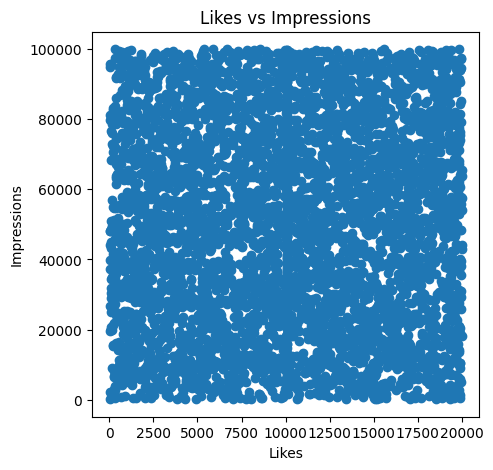

In [37]:
# Scatter Plot
plt.figure(figsize=(5,5))
plt.scatter(df['likes'],df['impression_count'])
plt.title('Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.show()

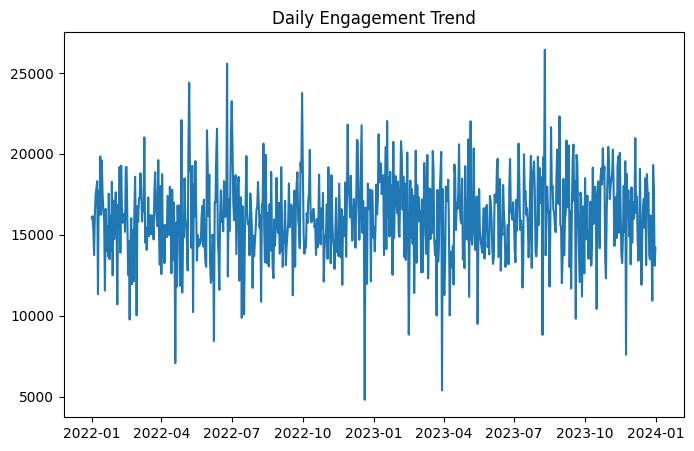

In [43]:
# Line Chart

df['engagement_score'] = (
    df['likes'] +
    df['comments']*2 +
    df['shares']*3
)

daily = df.groupby('posted_at')['engagement_score'].mean()

plt.figure(figsize=(8,5))
plt.plot(daily)
plt.title('Daily Engagement Trend')
plt.show()

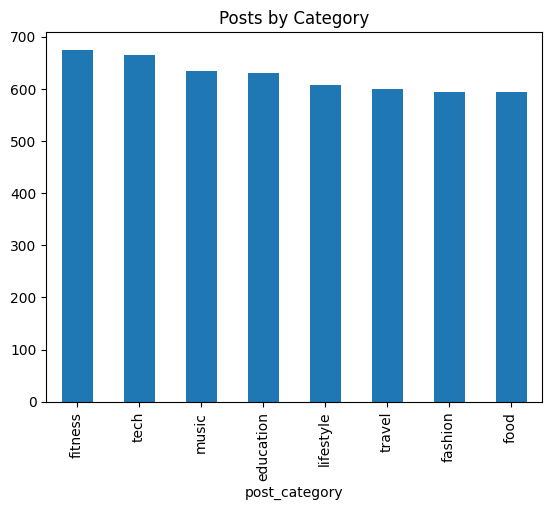

In [45]:
# Bar Chart
df['post_category'].value_counts().plot(kind='bar')

plt.title('Posts by Category')
plt.show()

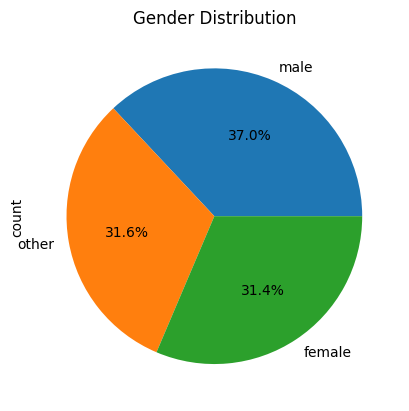

In [46]:
# Pie Chart

df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.show()

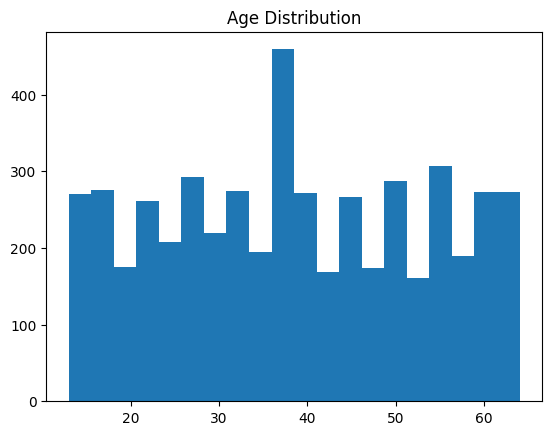

In [47]:
# Histogram

plt.hist(df['age'],bins=20)

plt.title('Age Distribution')
plt.show()

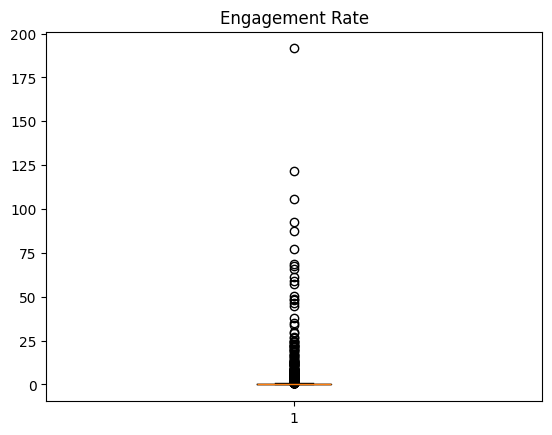

In [48]:
# Box Plot


plt.boxplot(df['engagement_rate'])

plt.title('Engagement Rate')
plt.show()

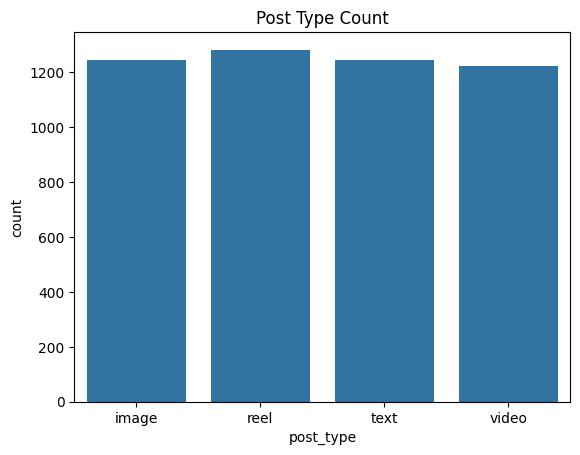

In [49]:
# Count Plot
sns.countplot(
    data=df,
    x='post_type'
)

plt.title('Post Type Count')
plt.show()

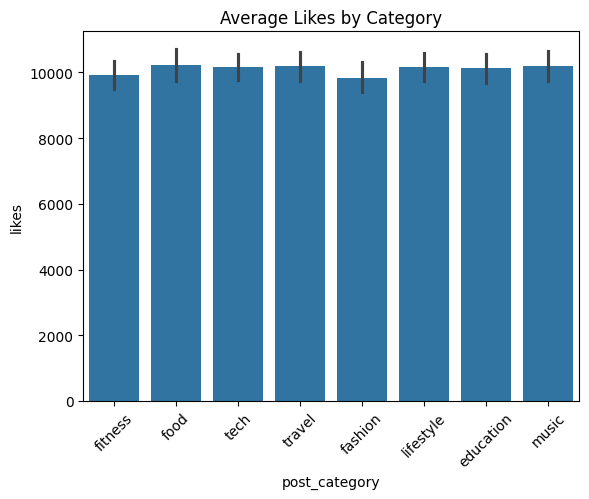

In [51]:
# Bar Plot
sns.barplot(
    data=df,
    x='post_category',
    y='likes'
)

plt.title('Average Likes by Category')
plt.xticks(rotation=45)
plt.show()

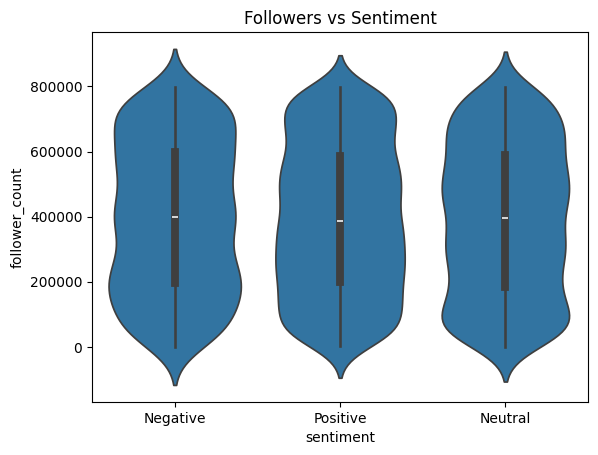

In [53]:
# Violin Plot
sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count'
)

plt.title('Followers vs Sentiment')
plt.show()

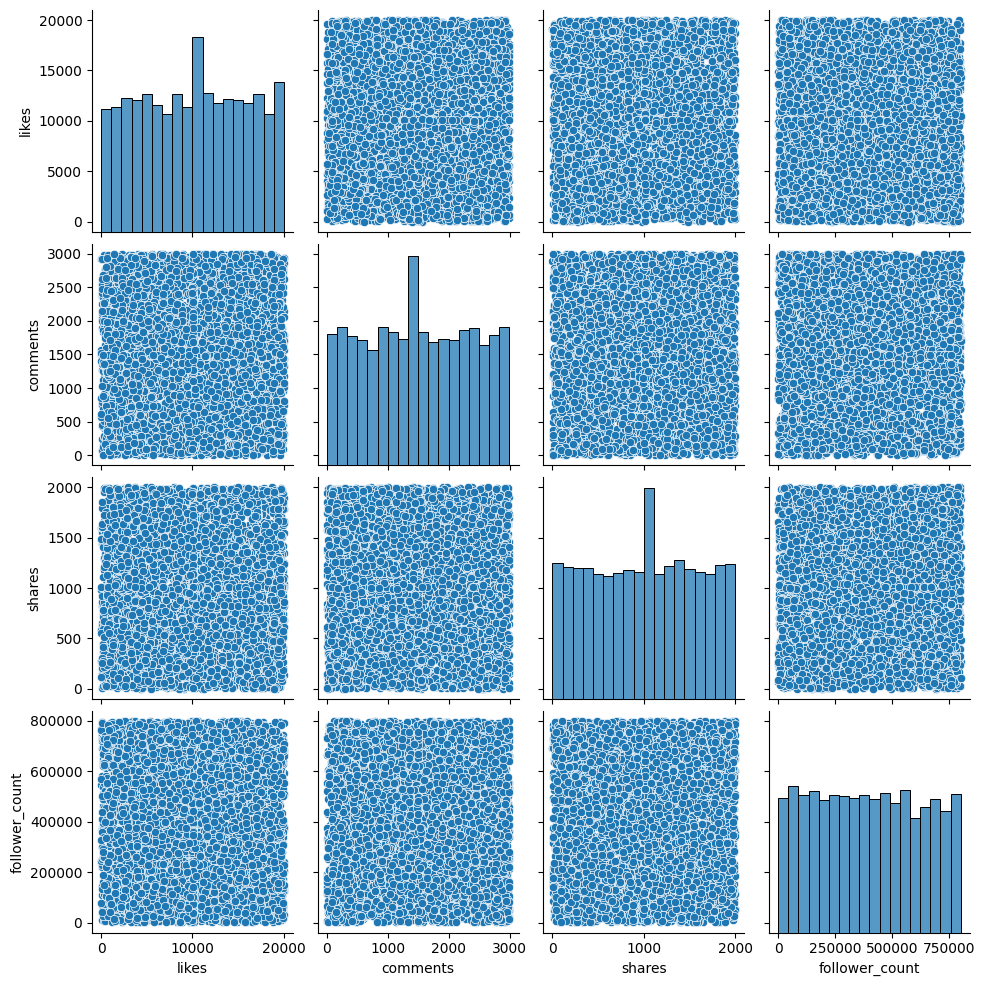

In [55]:
# Pair Plot
sns.pairplot(
    df[['likes',
        'comments',
        'shares',
        'follower_count']]
)
plt.show()

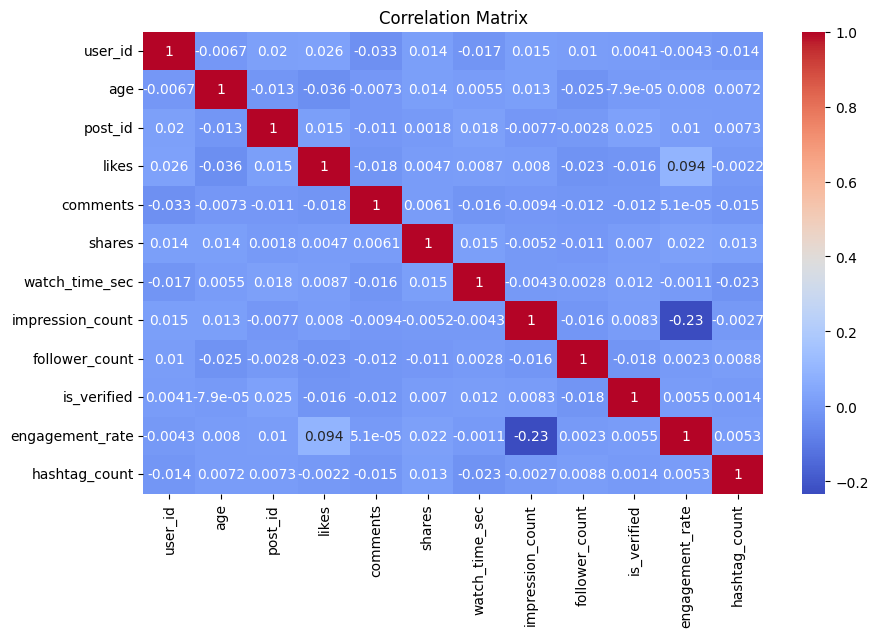

In [56]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 95.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 95.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 95.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 95.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 96.3% of the points cannot be plac

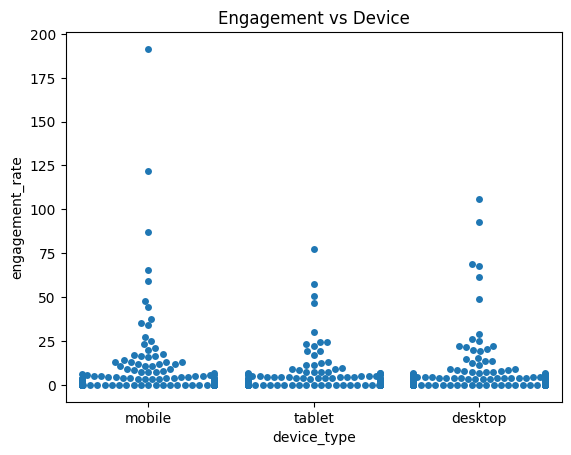

In [58]:
# Swarm Plot
sns.swarmplot(
    data=df,
    x='device_type',
    y='engagement_rate'
)

plt.title('Engagement vs Device')
plt.show()

In [60]:
# Plotly Interactive Chart
fig = px.scatter(
    df,
    x='impression_count',
    y='likes',
    color='post_type',
    size='engagement_rate',
    title='Interactive Social Media Analysis'
)

fig.show()